# 🔧 PHẦN 0: IMPORTS & CẤU HÌNH CHUNG

Import tất cả thư viện cần thiết và khai báo các hằng số dùng chung trong toàn bộ notebook.

In [1]:
import cv2
import numpy as np
import os
import pickle
import threading
import time
import io
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output

import faiss
from insightface.app import FaceAnalysis
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import pandas as pd

# ==========================================
# CẤU HÌNH TOÀN CỤC
# ==========================================
DATASET_PATH = "Dataset Split Filtered\\train"  # Thư mục train
TEST_DIR     = "Dataset Split Filtered\\test"    # Thư mục test
DB_L_PATH    = "face_db_0.pkl"                  # DB dùng model buffalo_l
DB_S_PATH    = "face_db_1.pkl"                  # DB dùng model buffalo_s
THRESHOLD    = 0.5                              # Ngưỡng nhận diện

# Điểm tham chiếu 5 landmarks chuẩn 112x112 (dùng cho Face Alignment)
ARCFACE_SRC_PTS = np.array([
    [38.2946, 51.6963],  # Mắt trái
    [73.5318, 51.5014],  # Mắt phải
    [56.0252, 71.7366],  # Mũi
    [41.5493, 92.3655],  # Mép trái
    [70.7299, 92.2041],  # Mép phải
], dtype=np.float32)

print("✅ Đã import xong tất cả thư viện!")


✅ Đã import xong tất cả thư viện!


# 📐 PHẦN 1: TIỀN XỬ LÝ – FACE ALIGNMENT

Hàm `align_face()` dùng 5 điểm landmarks (SCRFD) để xoay và cắt khuôn mặt về kích thước chuẩn **112×112 px** bằng phép biến đổi Affine.

In [ ]:
def align_face(img, landmarks):
    """
    Căn chỉnh khuôn mặt về kích thước chuẩn 112x112 dựa trên 5 điểm landmarks.
    - dst_pts: 5 điểm SCRFD tìm được trên ảnh gốc
    - src_pts: 5 điểm tham chiếu chuẩn (ARCFACE_SRC_PTS)
    - Dùng Least Squares Affine (cv2.LMEDS) để tìm ma trận xoay/dịch 2×3
    """
    dst_pts = np.array(landmarks, dtype=np.float32)
    M, _ = cv2.estimateAffinePartial2D(dst_pts, ARCFACE_SRC_PTS, method=cv2.LMEDS)
    if M is None:
        return None
    aligned = cv2.warpAffine(img, M, (112, 112), borderValue=0.0)
    return aligned


# ── Demo: Cắt & hiển thị mặt từ ảnh tĩnh ────────────────────────────
def crop_faces(image_path, save=True):
    """Phát hiện và cắt tất cả khuôn mặt trong một ảnh (tùy chọn lưu file)."""
    app = FaceAnalysis(name='buffalo_l', allowed_modules=['detection'])
    app.prepare(ctx_id=0, det_size=(640, 640))

    img = cv2.imread(image_path)
    if img is None:
        print("❌ Không thể đọc ảnh:", image_path)
        return []

    faces = app.get(img)
    cropped = []
    for i, face in enumerate(faces):
        aligned = align_face(img, face.kps)
        if aligned is not None:
            cropped.append(aligned)
            if save:
                cv2.imwrite(f'face_{i}.jpg', aligned)
                print(f"✅ Đã lưu face_{i}.jpg")
    return cropped


def detect_and_show_faces(image_path):
    """Phát hiện khuôn mặt và hiển thị các mặt đã căn chỉnh bằng Matplotlib."""
    app = FaceAnalysis(name='buffalo_l', allowed_modules=['detection'])
    app.prepare(ctx_id=0, det_size=(640, 640))

    img = cv2.imread(image_path)
    if img is None:
        print("❌ Không tìm thấy ảnh!")
        return

    faces = app.get(img)
    if not faces:
        print("Không tìm thấy khuôn mặt nào.")
        return

    plt.figure(figsize=(15, 5))
    for i, face in enumerate(faces):
        aligned = align_face(img, face.kps)
        if aligned is not None:
            plt.subplot(1, len(faces), i + 1)
            plt.imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
            plt.title(f"Face {i+1}")
            plt.axis('off')
    plt.tight_layout()
    plt.show()


# ── Chạy thử ─────────────────────────────────────────────────────────
# detect_and_show_faces('Dataset Split Filtered\\test\\Tri\\IMG_0208_f01142.jpg')
# crop_faces('Dataset Split Filtered\\test\\Dan\\7760755191496_f00194.jpg')


# 🗄️ PHẦN 2A: XÂY DỰNG DATABASE – Model `buffalo_l` (Chính xác cao)

Trích xuất embedding ArcFace cho toàn bộ ảnh train, lấy trung bình vector (Mean Pooling) mỗi người, chuẩn hóa L2 rồi lưu vào `face_db_0.pkl`.

In [ ]:
import os
import cv2
import numpy as np
import pickle
from insightface.app import FaceAnalysis

def build_database(dataset_path="Dataset Split Filtered\\train", db_save_path="face_db_0.pkl"):
    print("🚀 Đang khởi tạo mô hình trích xuất (InsightFace - buffalo_s)...")
    
    # [CÁCH 2]: Gọi bộ mô hình 'buffalo_s' siêu nhẹ
    app = FaceAnalysis(name='buffalo_l', allowed_modules=['detection', 'recognition'])
    
    # [CÁCH 1]: Chuyển ctx_id = 0 để ép chạy bằng GPU
    app.prepare(ctx_id=0, det_size=(640, 640)) 
    
    known_vectors = []
    known_names = []
    
    if not os.path.exists(dataset_path):
        print(f"❌ Không tìm thấy thư mục '{dataset_path}'!")
        return

    print(f"\n📂 Bắt đầu quét thư mục: {dataset_path}")
    
    for person_name in os.listdir(dataset_path):
        person_dir = os.path.join(dataset_path, person_name)
        if not os.path.isdir(person_dir):
            continue
            
        print(f"  👉 Đang xử lý cho: {person_name}...")
        person_vectors = []
        
        for image_name in os.listdir(person_dir):
            img_path = os.path.join(person_dir, image_name)
            img = cv2.imread(img_path)
            
            if img is None: continue
                
            faces = app.get(img)
            
            if len(faces) > 0:
                # Ưu tiên lấy mặt to nhất nếu có nhiều người trong 1 ảnh
                faces = sorted(faces, key=lambda x: (x.bbox[2]-x.bbox[0]) * (x.bbox[3]-x.bbox[1]), reverse=True)
                person_vectors.append(faces[0].embedding)
                
        # Gộp các vector (Mean Pooling)
        if len(person_vectors) > 0:
            mean_vector = np.mean(person_vectors, axis=0)
            mean_vector = mean_vector / np.linalg.norm(mean_vector) # Chuẩn hóa L2
            
            known_vectors.append(mean_vector)
            known_names.append(person_name)
            print(f"     ✅ Đã tạo xong vector cho {person_name} (từ {len(person_vectors)} ảnh).")
            
    with open(db_save_path, 'wb') as f:
        pickle.dump({"names": known_names, "vectors": known_vectors}, f)
        
    print(f"\n🎉 HOÀN TẤT! Đã lưu dữ liệu của {len(known_names)} người vào '{db_save_path}'.")

if __name__ == "__main__":
    build_database()

# 🗄️ PHẦN 2B: XÂY DỰNG DATABASE – Model `buffalo_s` (Nhẹ, nhanh)

Tương tự 2A nhưng dùng `buffalo_s` (nhỏ hơn, nhanh hơn), lưu vào `face_db_1.pkl`.

In [ ]:
import os
import cv2
import numpy as np
import pickle
from insightface.app import FaceAnalysis

def build_database(dataset_path="Dataset Split Filtered\\train", db_save_path="face_db_1.pkl"):
    print("🚀 Đang khởi tạo mô hình trích xuất (InsightFace - buffalo_s)...")
    
    # [CÁCH 2]: Gọi bộ mô hình 'buffalo_s' siêu nhẹ
    app = FaceAnalysis(name='buffalo_s', allowed_modules=['detection', 'recognition'])
    
    # [CÁCH 1]: Chuyển ctx_id = 0 để ép chạy bằng GPU
    app.prepare(ctx_id=0, det_size=(640, 640)) 
    
    known_vectors = []
    known_names = []
    
    if not os.path.exists(dataset_path):
        print(f"❌ Không tìm thấy thư mục '{dataset_path}'!")
        return

    print(f"\n📂 Bắt đầu quét thư mục: {dataset_path}")
    
    for person_name in os.listdir(dataset_path):
        person_dir = os.path.join(dataset_path, person_name)
        if not os.path.isdir(person_dir):
            continue
            
        print(f"  👉 Đang xử lý cho: {person_name}...")
        person_vectors = []
        
        for image_name in os.listdir(person_dir):
            img_path = os.path.join(person_dir, image_name)
            img = cv2.imread(img_path)
            
            if img is None: continue
                
            faces = app.get(img)
            
            if len(faces) > 0:
                # Ưu tiên lấy mặt to nhất nếu có nhiều người trong 1 ảnh
                faces = sorted(faces, key=lambda x: (x.bbox[2]-x.bbox[0]) * (x.bbox[3]-x.bbox[1]), reverse=True)
                person_vectors.append(faces[0].embedding)
                
        # Gộp các vector (Mean Pooling)
        if len(person_vectors) > 0:
            mean_vector = np.mean(person_vectors, axis=0)
            mean_vector = mean_vector / np.linalg.norm(mean_vector) # Chuẩn hóa L2
            
            known_vectors.append(mean_vector)
            known_names.append(person_name)
            print(f"     ✅ Đã tạo xong vector cho {person_name} (từ {len(person_vectors)} ảnh).")
            
    with open(db_save_path, 'wb') as f:
        pickle.dump({"names": known_names, "vectors": known_vectors}, f)
        
    print(f"\n🎉 HOÀN TẤT! Đã lưu dữ liệu của {len(known_names)} người vào '{db_save_path}'.")

if __name__ == "__main__":
    build_database()

# 📊 PHẦN 3: ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST

Chạy nhận diện toàn bộ tập test, tính Accuracy / Precision / Recall / F1, vẽ Confusion Matrix và hiển thị lưới ảnh nhận diện sai.

📦 Đang tải Database: face_db_1.pkl
🧠 Đang khởi tạo Model: buffalo_s
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\MSII/.insightface\models\buffalo_s\1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\MSII/.insightface\models\buffalo_s\2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\MSII/.insightface\models\buffalo_s\det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\MSII/.insightface\models\buffalo_s\genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\MSII/.insightface\models\buffalo_s\w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-si

c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
C:\Users\MSII\AppData\Local\Temp\ipykernel_35040\3962366506.py:122: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
C:\Users\MSII\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


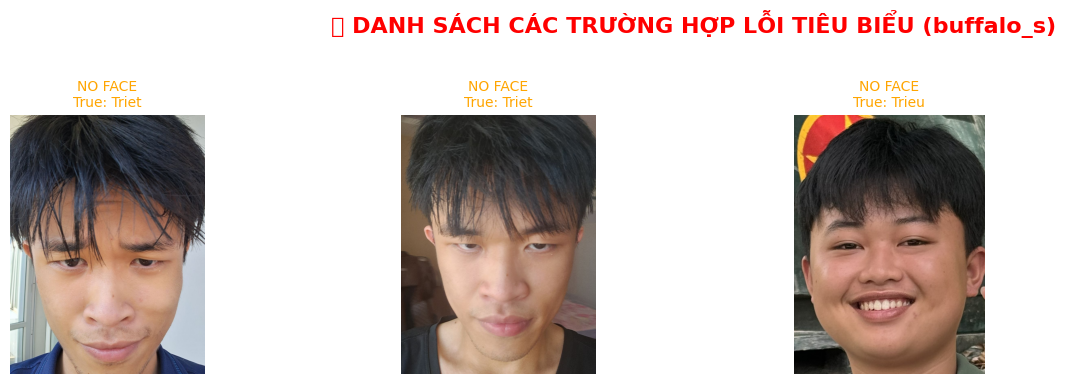


📊 KẾT QUẢ: Acc: 0.9400 | F1: 0.8060


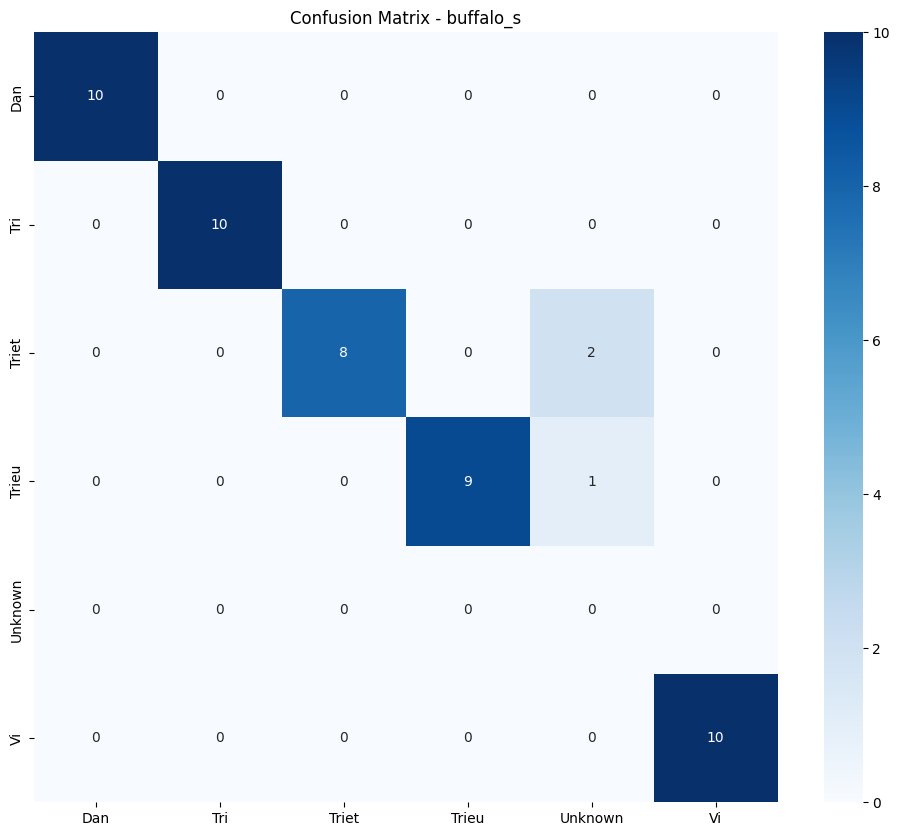


📊 BẢNG CHI TIẾT ĐÁNH GIÁ ĐỊNH DANH (buffalo_s)
         Precision Recall F1-score Số mẫu test
Dan         1.0000 1.0000   1.0000          10
Tri         1.0000 1.0000   1.0000          10
Triet       1.0000 0.8000   0.8889          10
Trieu       1.0000 0.9000   0.9474          10
Vi          1.0000 1.0000   1.0000          10
Accuracy         —        —     0.9400          47


In [2]:
import os
import cv2
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from insightface.app import FaceAnalysis

# ==========================================
# 1. CẤU HÌNH THÔNG SỐ
# ==========================================
TEST_DIR = "test"
DB_PATH = "face_db_1.pkl"
MODEL_NAME = "buffalo_s"
THRESHOLD = 0.5
SAVE_MISSED = "missed_results"
MAX_ERRORS_TO_SHOW = 12  # Số lượng ảnh lỗi tối đa hiển thị trên lưới (ví dụ: lưới 3x4 hoặc 4x3)

os.makedirs(SAVE_MISSED, exist_ok=True)

# ==========================================
# 2. LOAD DATABASE & MODEL
# ==========================================
def load_resources():
    print(f"📦 Đang tải Database: {DB_PATH}")
    with open(DB_PATH, 'rb') as f:
        db_data = pickle.load(f)
    db_data["vectors"] = np.array(db_data["vectors"]).astype('float32')
    
    print(f"🧠 Đang khởi tạo Model: {MODEL_NAME}")
    app = FaceAnalysis(name=MODEL_NAME, allowed_modules=['detection', 'recognition'])
    app.prepare(ctx_id=0, det_size=(640, 640)) 
    return db_data, app

def get_best_match(embedding, db_data, threshold):
    norm_query = embedding / np.linalg.norm(embedding)
    similarities = np.dot(db_data["vectors"], norm_query)
    idx = np.argmax(similarities)
    score = similarities[idx]
    
    if score >= threshold:
        return db_data["names"][idx], score
    return "Unknown", score

# ==========================================
# 3. CHẠY EVALUATION & HIỂN THỊ LƯỚI
# ==========================================
def evaluate():
    db_data, app = load_resources()
    y_true, y_pred = [], []
    error_gallery = [] # Danh sách lưu trữ các trường hợp lỗi để vẽ lưới

    all_classes = sorted([d for d in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, d))])
    
    print(f"\n🔍 Đang quét dữ liệu test...")

    for label in all_classes:
        label_dir = os.path.join(TEST_DIR, label)
        image_files = os.listdir(label_dir)
        
        for img_name in image_files:
            img_path = os.path.join(label_dir, img_name)
            img = cv2.imread(img_path)
            if img is None: continue
            
            y_true.append(label)
            faces = app.get(img)
            
            # --- TRƯỜNG HỢP KHÔNG DETECT ĐƯỢC ---
            if len(faces) == 0:
                pred_label = "Unknown"
                y_pred.append(pred_label)
                
                # Lưu thông tin lỗi
                if len(error_gallery) < MAX_ERRORS_TO_SHOW:
                    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    error_gallery.append({
                        "img": img_display,
                        "title": f"NO FACE\nTrue: {label}",
                        "color": "orange"
                    })
                cv2.imwrite(os.path.join(SAVE_MISSED, f"NODETECT_{label}_{img_name}"), img)
                continue

            # --- TRƯỜNG HỢP CÓ MẶT -> NHẬN DIỆN ---
            faces = sorted(faces, key=lambda x: (x.bbox[2]-x.bbox[0])*(x.bbox[3]-x.bbox[1]), reverse=True)
            face = faces[0]
            pred_label, score = get_best_match(face.embedding, db_data, THRESHOLD)
            y_pred.append(pred_label)

            if pred_label != label:
                # Vẽ box lên ảnh lỗi để lưu
                bbox = face.bbox.astype(int)
                img_copy = img.copy()
                cv2.rectangle(img_copy, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 0, 255), 2)
                
                if len(error_gallery) < MAX_ERRORS_TO_SHOW:
                    img_display = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
                    error_gallery.append({
                        "img": img_display,
                        "title": f"WRONG ({score:.2f})\nT: {label} | P: {pred_label}",
                        "color": "red"
                    })
                cv2.imwrite(os.path.join(SAVE_MISSED, f"WRONG_{label}_as_{pred_label}_{img_name}"), img_copy)

    # --- HIỂN THỊ LƯỚI ẢNH LỖI ---
    if error_gallery:
        num_errors = len(error_gallery)
        cols = 4
        rows = (num_errors + cols - 1) // cols
        
        plt.figure(figsize=(16, 4 * rows))
        plt.suptitle(f"📸 DANH SÁCH CÁC TRƯỜNG HỢP LỖI TIÊU BIỂU ({MODEL_NAME})", fontsize=16, color='red', fontweight='bold')
        
        for i, item in enumerate(error_gallery):
            plt.subplot(rows, cols, i + 1)
            plt.imshow(item["img"])
            plt.title(item["title"], fontsize=10, color=item["color"])
            plt.axis('off')
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    # --- IN METRICS ---
    labels_in_data = sorted(list(set(y_true) | set(y_pred)))
    print("\n" + "="*40)
    print(f"📊 KẾT QUẢ: Acc: {accuracy_score(y_true, y_pred):.4f} | F1: {f1_score(y_true, y_pred, average='macro', labels=labels_in_data, zero_division=0):.4f}")
    print("="*40)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels_in_data)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_in_data, yticklabels=labels_in_data)
    plt.title(f'Confusion Matrix - {MODEL_NAME}')
    plt.show()
    # --- IN METRICS & BẢNG CHI TIẾT ---
    from sklearn.metrics import classification_report
    import pandas as pd

    # Lấy danh sách các nhãn thực tế (loại bỏ 'Unknown' nếu bạn chỉ muốn tính trên các danh tính đã biết)
    # Hoặc để nguyên để xem model bắt 'Unknown' tốt không
    report_labels = sorted([c for c in all_classes]) 
    
    # Tạo dictionary báo cáo
    report_dict = classification_report(y_true, y_pred, labels=report_labels, output_dict=True, zero_division=0)
    
    # Chuyển đổi sang DataFrame để in bảng
    df_report = pd.DataFrame(report_dict).transpose()
    
    # Lọc lấy các cột cần thiết và đổi tên cho giống ảnh yêu cầu
    # 'support' chính là số mẫu test
    df_display = df_report.loc[report_labels, ['precision', 'recall', 'f1-score', 'support']]
    df_display.columns = ['Precision', 'Recall', 'F1-score', 'Số mẫu test']
    
    # Tính Accuracy tổng quát
    acc_val = accuracy_score(y_true, y_pred)
    
    # Thêm dòng Accuracy vào cuối bảng
    df_display.loc['Accuracy'] = [None, None, acc_val, accuracy_score(y_true, y_pred, normalize=False)]

    print("\n" + "="*60)
    print(f"📊 BẢNG CHI TIẾT ĐÁNH GIÁ ĐỊNH DANH ({MODEL_NAME})")
    print("="*60)
    # Định dạng in số thập phân 4 chữ số
    print(df_display.to_string(formatters={
        'Precision': '{:,.4f}'.format,
        'Recall': '{:,.4f}'.format,
        'F1-score': '{:,.4f}'.format,
        'Số mẫu test': '{:.0f}'.format
    }).replace('NaN', '  —  ').replace('None', '  —  '))
    print("="*60)

    # (Phần vẽ Confusion Matrix giữ nguyên bên dưới...)

if __name__ == "__main__":
    evaluate()

# 🧩 PHẦN 4: CLASSES DÙNG CHUNG – VideoStream & AIWorker

Hai class này dùng đa luồng (threading) để:
- **VideoStream**: liên tục đọc frame từ webcam (non-blocking)
- **AIWorker**: chạy AI nhận diện ở luồng nền, không làm trễ camera

In [3]:
import cv2
import numpy as np
import threading
import time

# ==========================================
# CLASS 1: ĐỌC WEBCAM ASYNC
# ==========================================
class VideoStream:
    def __init__(self, src=0, width=640, height=480):
        self.stream = cv2.VideoCapture(src)
        self.stream.set(cv2.CAP_PROP_FRAME_WIDTH, width)
        self.stream.set(cv2.CAP_PROP_FRAME_HEIGHT, height)
        (self.grabbed, self.frame) = self.stream.read()
        self.stopped = False

    def start(self):
        threading.Thread(target=self.update, args=(), daemon=True).start()
        return self

    def update(self):
        while not self.stopped:
            (self.grabbed, self.frame) = self.stream.read()

    def read(self):
        return self.frame

    def stop(self):
        self.stopped = True
        self.stream.release()


# ==========================================
# CLASS 2: LUỒNG CHẠY AI NGẦM (FAISS)
# ==========================================
class AIWorker(threading.Thread):
    def __init__(self, app, faiss_index, known_names, threshold=0.5):
        threading.Thread.__init__(self)
        self.app          = app
        self.faiss_index  = faiss_index
        self.known_names  = known_names
        self.threshold    = threshold
        self.frame_to_process = None
        self.results      = []
        self.running      = True
        self.daemon       = True

    def update_frame(self, frame):
        # Chỉ nhận frame mới khi đã xử lý xong frame cũ
        if self.frame_to_process is None:
            self.frame_to_process = frame.copy() if frame is not None else None

    def run(self):
        while self.running:
            if self.frame_to_process is not None:
                faces = self.app.get(self.frame_to_process)
                processed = []
                for face in faces:
                    bbox = face.bbox.astype(int)
                    vec  = face.embedding / np.linalg.norm(face.embedding)
                    query = np.array([vec]).astype('float32')
                    distances, indices = self.faiss_index.search(query, k=1)
                    score    = distances[0][0]
                    match_id = indices[0][0]
                    name = self.known_names[match_id].replace('_', ' ') if score > self.threshold else 'Unknown'
                    processed.append((bbox, name, score))
                self.results = processed
                self.frame_to_process = None
            else:
                time.sleep(0.01)


def load_faiss_db(db_path):
    """Load database .pkl và tạo FAISS IndexFlatIP (Inner Product = Cosine sau L2 norm)."""
    with open(db_path, 'rb') as f:
        data = pickle.load(f)
    names   = data['names']
    vectors = np.array(data['vectors']).astype('float32')
    index   = faiss.IndexFlatIP(512)
    index.add(vectors)
    print(f"✅ Đã load DB '{db_path}' — {len(names)} người.")
    return names, index


print("✅ Classes VideoStream, AIWorker và hàm load_faiss_db đã sẵn sàng!")


✅ Classes VideoStream, AIWorker và hàm load_faiss_db đã sẵn sàng!


# 🎥 PHẦN 5A: WEBCAM REALTIME – Model `buffalo_l` + `face_db_0.pkl`

Chạy nhận diện realtime với model buffalo_l (độ chính xác cao hơn, nặng hơn). Nhấn **Q** để thoát.

In [4]:
def main():
    print("Đang tải dữ liệu DB (buffalo_l)...")
    known_names, faiss_index = load_faiss_db(DB_L_PATH)

    print("Đang khởi tạo mô hình AI (buffalo_l)...")
    app = FaceAnalysis(name='buffalo_l', allowed_modules=['detection', 'recognition'])
    app.prepare(ctx_id=0, det_size=(320, 320))

    print("\n🎥 KHỞI ĐỘNG WEBCAM ASYNC... Nhấn 'q' để thoát.")
    vs = VideoStream(src=0).start()
    time.sleep(1.0)

    ai_worker = AIWorker(app, faiss_index, known_names, threshold=THRESHOLD)
    ai_worker.start()

    while True:
        frame = vs.read()
        if frame is None: continue
        frame = cv2.flip(frame, 1)
        ai_worker.update_frame(frame)

        for bbox, name, score in ai_worker.results:
            color = (0, 255, 0) if name != 'Unknown' else (0, 0, 255)
            cv2.rectangle(frame, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2)
            text = f"{name} ({score:.2f})"
            (w, h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(frame, (bbox[0], bbox[1]-20), (bbox[0]+w, bbox[1]), color, -1)
            cv2.putText(frame, text, (bbox[0], bbox[1]-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

        cv2.imshow('Face Recognition — buffalo_l', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    ai_worker.running = False
    vs.stop()
    cv2.destroyAllWindows()


if __name__ == '__main__':
    main()


Đang tải dữ liệu DB (buffalo_l)...
✅ Đã load DB 'face_db_0.pkl' — 7 người.
Đang khởi tạo mô hình AI (buffalo_l)...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\MSII/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\MSII/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\MSII/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\MSII/.insightface\models\buffalo_l\genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\MSII/.insightface\models\buffalo_l\w600k_r50.onnx recognitio

c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


# 🎥 PHẦN 5B: WEBCAM REALTIME – Model `buffalo_s` + `face_db_1.pkl`

Phiên bản nhẹ hơn với `buffalo_s` — phù hợp khi máy yếu hoặc cần FPS cao hơn. Nhấn **Q** để thoát.

In [5]:
def main():
    print("Đang tải dữ liệu DB (buffalo_s)...")
    known_names, faiss_index = load_faiss_db(DB_S_PATH)

    print("Đang khởi tạo mô hình AI (buffalo_s)...")
    app = FaceAnalysis(name='buffalo_s', allowed_modules=['detection', 'recognition'])
    app.prepare(ctx_id=0, det_size=(320, 320))

    print("\n🎥 KHỞI ĐỘNG WEBCAM ASYNC... Nhấn 'q' để thoát.")
    vs = VideoStream(src=0).start()
    time.sleep(1.0)

    ai_worker = AIWorker(app, faiss_index, known_names, threshold=THRESHOLD)
    ai_worker.start()

    while True:
        frame = vs.read()
        if frame is None: continue
        frame = cv2.flip(frame, 1)
        ai_worker.update_frame(frame)

        for bbox, name, score in ai_worker.results:
            color = (0, 255, 0) if name != 'Unknown' else (0, 0, 255)
            cv2.rectangle(frame, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2)
            text = f"{name} ({score:.2f})"
            (w, h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(frame, (bbox[0], bbox[1]-20), (bbox[0]+w, bbox[1]), color, -1)
            cv2.putText(frame, text, (bbox[0], bbox[1]-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

        cv2.imshow('Face Recognition — buffalo_s', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    ai_worker.running = False
    vs.stop()
    cv2.destroyAllWindows()


if __name__ == '__main__':
    main()


Đang tải dữ liệu DB (buffalo_s)...
✅ Đã load DB 'face_db_1.pkl' — 7 người.
Đang khởi tạo mô hình AI (buffalo_s)...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\MSII/.insightface\models\buffalo_s\1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\MSII/.insightface\models\buffalo_s\2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\MSII/.insightface\models\buffalo_s\det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: C:\Users\MSII/.insightface\models\buffalo_s\genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\MSII/.insightface\models\buffalo_s\w600k_mbf.onnx recogniti

# 🖥️ PHẦN 6: WEBCAM UI NÂNG CAO – Sidebar & Attendance Log

Giao diện webcam có sidebar hiển thị danh sách người đã nhận diện kèm giờ, và nút **RESET LIST**. Nhấn **Q** để thoát.

In [ ]:
import cv2
import numpy as np
import pickle
import os
import threading
import time
from datetime import datetime
from insightface.app import FaceAnalysis
import faiss 

# ==========================================
# CẤU HÌNH GIAO DIỆN
# ==========================================
WIN_NAME = "AI FACE RECOGNITION SYSTEM"
CAM_W, CAM_H = 640, 480
SIDEBAR_W = 250
CANVAS_W = CAM_W + SIDEBAR_W
COLOR_PRIMARY = (255, 150, 50)  # Màu xanh dương thương hiệu
COLOR_ACCENT = (0, 255, 100)   # Màu xanh lá (đã nhận diện)
COLOR_DANGER = (50, 50, 255)   # Màu đỏ

# ==========================================
# CÔNG NHÂN 1: ĐỌC WEBCAM ASYNC
# ==========================================
class VideoStream:
    def __init__(self, src=0):
        self.stream = cv2.VideoCapture(src)
        self.stream.set(cv2.CAP_PROP_FRAME_WIDTH, CAM_W)
        self.stream.set(cv2.CAP_PROP_FRAME_HEIGHT, CAM_H)
        (self.grabbed, self.frame) = self.stream.read()
        self.stopped = False

    def start(self):
        threading.Thread(target=self.update, args=(), daemon=True).start()
        return self

    def update(self):
        while not self.stopped:
            (self.grabbed, self.frame) = self.stream.read()

    def read(self):
        return self.frame

    def stop(self):
        self.stopped = True
        self.stream.release()

# ==========================================
# CÔNG NHÂN 2: LUỒNG CHẠY AI NGẦM
# ==========================================
class AIWorker(threading.Thread):
    def __init__(self, app, faiss_index, known_names, threshold):
        threading.Thread.__init__(self)
        self.app = app
        self.faiss_index = faiss_index
        self.known_names = known_names
        self.threshold = threshold
        self.frame_to_process = None
        self.results = []
        self.running = True
        self.daemon = True 

    def update_frame(self, frame):
        if self.frame_to_process is None: # Chỉ nhận frame mới khi đã xử lý xong frame cũ
            self.frame_to_process = frame.copy() if frame is not None else None

    def run(self):
        while self.running:
            if self.frame_to_process is not None:
                faces = self.app.get(self.frame_to_process)
                processed_faces = []
                
                for face in faces:
                    bbox = face.bbox.astype(int)
                    current_vector = face.embedding / np.linalg.norm(face.embedding)
                    
                    query = np.array([current_vector]).astype('float32')
                    distances, indices = self.faiss_index.search(query, k=1)
                    
                    score = distances[0][0]
                    match_id = indices[0][0]
                    
                    name = "Unknown"
                    if score > self.threshold:
                        name = self.known_names[match_id].replace("_", " ")
                    
                    processed_faces.append((bbox, name, score))
                
                self.results = processed_faces
                self.frame_to_process = None 
            else:
                time.sleep(0.01)

# ==========================================
# QUẢN LÝ DANH SÁCH NHẬN DIỆN (LOG)
# ==========================================
class AttendanceManager:
    def __init__(self):
        self.detected_list = {} # {name: time_string}

    def add(self, name):
        if name != "Unknown":
            now = datetime.now().strftime("%H:%M:%S")
            self.detected_list[name] = now

    def reset(self):
        self.detected_list.clear()

# ==========================================
# XỬ LÝ SỰ KIỆN CHUỘT (CHO NÚT RESET)
# ==========================================
reset_clicked = False
def on_mouse(event, x, y, flags, param):
    global reset_clicked
    if event == cv2.EVENT_LBUTTONDOWN:
        # Tọa độ nút Reset nằm ở sidebar bottom
        if CAM_W + 20 < x < CANVAS_W - 20 and CAM_H - 60 < y < CAM_H - 20:
            reset_clicked = True

# ==========================================
# HÀM CHÍNH
# ==========================================
def main():
    global reset_clicked
    # 1. Load Data
    with open("face_db_1.pkl", 'rb') as f:
        db_data = pickle.load(f)
    known_names, known_vectors = db_data["names"], db_data["vectors"]
    
    # 2. Khởi tạo FAISS
    faiss_index = faiss.IndexFlatIP(512)
    faiss_index.add(np.array(known_vectors).astype('float32'))
    
    # 3. Khởi tạo AI
    app = FaceAnalysis(name='buffalo_s', allowed_modules=['detection', 'recognition'])
    app.prepare(ctx_id=0, det_size=(320, 320))

    # 4. Khởi tạo Components
    vs = VideoStream(src=0).start()
    ai_worker = AIWorker(app, faiss_index, known_names, threshold=0.5)
    ai_worker.start()
    manager = AttendanceManager()

    cv2.namedWindow(WIN_NAME)
    cv2.setMouseCallback(WIN_NAME, on_mouse)

    while True:
        raw_frame = vs.read()
        if raw_frame is None: break
        
        # Tạo canvas tổng thể màu tối sang trọng
        canvas = np.zeros((CAM_H, CANVAS_W, 3), dtype="uint8")
        canvas[:] = (30, 30, 30) # Màu nền xám đậm
        
        # Lật camera và đưa vào canvas
        frame_view = cv2.flip(raw_frame, 1)
        canvas[0:CAM_H, 0:CAM_W] = frame_view
        
        # Gửi frame cho công nhân AI
        ai_worker.update_frame(frame_view)
        
        # Vẽ kết quả AI
        for bbox, name, score in ai_worker.results:
            color = COLOR_ACCENT if name != "Unknown" else COLOR_DANGER
            cv2.rectangle(canvas, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2)
            
            # Label
            label = f"{name} {int(score*100)}%"
            cv2.putText(canvas, label, (bbox[0], bbox[1]-10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
            
            # Thêm vào danh sách log
            manager.add(name)

        # ---------------------------------------------------------
        # VẼ SIDEBAR (UX)
        # ---------------------------------------------------------
        # Tiêu đề Sidebar
        cv2.putText(canvas, "DETECTED LOG", (CAM_W + 20, 40), 
                    cv2.FONT_HERSHEY_DUPLEX, 0.7, (255, 255, 255), 1)
        cv2.line(canvas, (CAM_W + 20, 55), (CANVAS_W - 20, 55), (100, 100, 100), 1)

        # Hiển thị danh sách (Tối đa 10 người gần nhất)
        y_offset = 90
        for name, timestamp in list(manager.detected_list.items())[-10:]:
            # Vẽ hình tròn nhỏ đánh dấu
            cv2.circle(canvas, (CAM_W + 30, y_offset - 5), 4, COLOR_ACCENT, -1)
            # Vẽ Tên
            cv2.putText(canvas, f"{name[:15]}", (CAM_W + 45, y_offset), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
            # Vẽ Giờ
            cv2.putText(canvas, f"{timestamp}", (CANVAS_W - 75, y_offset), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (120, 120, 120), 1)
            y_offset += 30

        # Vẽ Nút Reset (UX)
        btn_color = (80, 80, 80)
        if reset_clicked:
            btn_color = COLOR_DANGER
            manager.reset()
            reset_clicked = False
            
        cv2.rectangle(canvas, (CAM_W + 20, CAM_H - 60), (CANVAS_W - 20, CAM_H - 20), btn_color, -1)
        cv2.putText(canvas, "RESET LIST", (CAM_W + 75, CAM_H - 33), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        # Hiển thị Canvas
        cv2.imshow(WIN_NAME, canvas)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    vs.stop()
    ai_worker.running = False
    cv2.destroyAllWindows()

if __name__ == '__main__':
    main()

# 📸 PHẦN 7: CHỤP ẢNH TỪ CAMERA & NHẬN DIỆN TRONG NOTEBOOK

Mở cửa sổ OpenCV camera, nhấn **SPACE** để chụp, kết quả hiển thị bằng Matplotlib trong notebook. Nhấn **Q** để thoát không chụp.

In [ ]:
# ==========================================
# CELL MỚI: BẬT CAMERA → CHỤP ẢNH → NHẬN DIỆN KHUÔN MẶT
# ==========================================
# Hướng dẫn: Copy toàn bộ code này vào 1 cell mới trong notebook
# SRCFD_ARCFACE_FAISS.ipynb rồi chạy.
#
# Cách dùng:
#   - Camera sẽ mở lên trong cửa sổ OpenCV
#   - Nhấn phím SPACE để chụp ảnh và nhận diện
#   - Nhấn phím 'q' để thoát
#   - Kết quả nhận diện sẽ hiển thị bằng matplotlib trong notebook
# ==========================================

import cv2
import numpy as np
import pickle
import matplotlib.pyplot as plt
from insightface.app import FaceAnalysis
import faiss
from IPython.display import display, clear_output

# --- 1. Khởi tạo Model và Database ---
print('🚀 Đang khởi tạo mô hình AI (InsightFace - buffalo_s)...')
app_cam = FaceAnalysis(name='buffalo_s', allowed_modules=['detection', 'recognition'])
app_cam.prepare(ctx_id=0, det_size=(640, 640))

print('📦 Đang tải Database từ face_db_1.pkl...')
with open('face_db_1.pkl', 'rb') as f:
    db_data = pickle.load(f)
known_names_cam = db_data['names']
known_vectors_cam = db_data['vectors']

faiss_index_cam = faiss.IndexFlatIP(512)
faiss_index_cam.add(np.array(known_vectors_cam).astype('float32'))
print(f'✅ Sẵn sàng! Database có {len(known_names_cam)} người: {known_names_cam}')

# --- 2. Hàm nhận diện ---
THRESHOLD = 0.5

def recognize_faces(img_bgr):
    """Nhận diện tất cả khuôn mặt trong ảnh BGR, trả về ảnh đã vẽ + danh sách kết quả."""
    img_draw = img_bgr.copy()
    faces = app_cam.get(img_bgr)

    if len(faces) == 0:
        return img_draw, []

    results = []
    for face in faces:
        bbox = face.bbox.astype(int)
        emb = face.embedding / np.linalg.norm(face.embedding)
        query = np.array([emb]).astype('float32')

        distances, indices = faiss_index_cam.search(query, k=1)
        score = distances[0][0]
        match_id = indices[0][0]

        name = 'Unknown'
        if score > THRESHOLD:
            name = known_names_cam[match_id]

        results.append({'name': name, 'score': score, 'bbox': bbox})

        color = (0, 255, 0) if name != 'Unknown' else (0, 0, 255)
        cv2.rectangle(img_draw, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 3)
        label = f'{name} ({score:.2f})'
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
        cv2.rectangle(img_draw, (bbox[0], bbox[1]-th-10), (bbox[0]+tw, bbox[1]), color, -1)
        cv2.putText(img_draw, label, (bbox[0], bbox[1]-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)

    return img_draw, results

# --- 3. Bật camera, chụp ảnh, nhận diện ---
print('\n📷 Đang mở camera...')
print('   ➡️  Nhấn SPACE để chụp & nhận diện')
print('   ➡️  Nhấn Q để thoát\n')

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

if not cap.isOpened():
    print('❌ Không thể mở camera!')
else:
    captured_frame = None

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.flip(frame, 1)  # Lật gương cho tự nhiên

        # Hiển thị hướng dẫn lên khung hình camera
        cv2.putText(frame, "SPACE: Chup & Nhan dien  |  Q: Thoat",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
        cv2.imshow('Camera - Nhan SPACE de chup', frame)

        key = cv2.waitKey(1) & 0xFF
        if key == ord(' '):       # SPACE → chụp
            captured_frame = frame.copy()
            print('📸 Đã chụp! Đang nhận diện...')
            break
        elif key == ord('q'):     # Q → thoát
            print('👋 Đã thoát camera.')
            break

    cap.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)  # flush

    # --- 4. Nhận diện và hiển thị kết quả trong notebook ---
    if captured_frame is not None:
        img_result, results = recognize_faces(captured_frame)
        img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

        fig, ax = plt.subplots(1, 1, figsize=(12, 8))
        ax.imshow(img_rgb)
        ax.set_title(f'Kết quả nhận diện — {len(results)} khuôn mặt', fontsize=14)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

        print('\n' + '='*50)
        print(f'📊 KẾT QUẢ: {len(results)} khuôn mặt')
        print('='*50)
        if len(results) == 0:
            print('  ⚠️ Không tìm thấy khuôn mặt nào!')
        for i, r in enumerate(results):
            status = '✅' if r['name'] != 'Unknown' else '❌'
            print(f"  {status} Mặt {i+1}: {r['name']}  —  Độ tin cậy: {r['score']:.4f}")
        print('='*50)
    else:
        print('ℹ️ Không có ảnh nào được chụp.')


# 📤 PHẦN 8: UPLOAD ẢNH & NHẬN DIỆN (ipywidgets)

Giao diện widget cho phép upload ảnh từ máy tính, tự động nhận diện và hiển thị kết quả ngay trong notebook.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pickle
import io
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output
from insightface.app import FaceAnalysis

# 1. TẢI DATABASE
try:
    with open('face_db_1.pkl', 'rb') as f:
        db_data = pickle.load(f)
    known_names = db_data["names"]
    known_vectors = np.array(db_data["vectors"])
except:
    print("❌ Không tìm thấy file face_db_1.pkl!")

# 2. KHỞI TẠO MÔ HÌNH
app = FaceAnalysis(name='buffalo_s', allowed_modules=['detection', 'recognition'])
app.prepare(ctx_id=0, det_size=(640, 640))

def process_upload(change):
    clear_output(wait=True)
    display(upload_button)
    
    if not upload_button.value:
        return

    # Đọc ảnh
    file_info = upload_button.value[0]
    content = file_info['content']
    image = Image.open(io.BytesIO(content))
    img_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    
    # --- TÍNH TOÁN ĐỘ ĐẬM NÉT DỰA TRÊN KÍCH THƯỚC ẢNH ---
    h, w, _ = img_cv.shape
    base_thick = max(2, int(w / 250))       # Độ dày khung
    font_scale = w / 700                   # Cỡ chữ (tỉ lệ thuận với chiều rộng)
    text_thickness = max(2, int(base_thick / 1.5)) # Độ đậm của nét chữ

    faces = app.get(img_cv)
    img_display = img_cv.copy()
    
    for face in faces:
        # Nhận diện
        embedding = face.embedding
        embedding = embedding / np.linalg.norm(embedding)
        similarities = np.dot(known_vectors, embedding)
        best_match_idx = np.argmax(similarities)
        score = similarities[best_match_idx]
        
        name = "Unknown"
        color = (0, 0, 255) # Đỏ
        if score > 0.45:
            name = known_names[best_match_idx]
            color = (0, 255, 0) # Xanh lá
            
        bbox = face.bbox.astype(int)
        
        # --- VẼ KHUNG ĐẬM ---
        cv2.rectangle(img_display, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, thickness=base_thick)
        
        # --- VẼ NỀN CHO CHỮ (Giúp chữ cực rõ) ---
        label = f"{name} ({score:.2f})"
        (label_w, label_h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_thickness)
        
        # Vẽ hình chữ nhật đặc làm nền sau chữ
        cv2.rectangle(img_display, 
                     (bbox[0], bbox[1] - label_h - 20), 
                     (bbox[0] + label_w, bbox[1]), 
                     color, -1) # -1 nghĩa là tô đặc màu
        
        # Viết chữ trắng lên nền màu đã tô
        cv2.putText(img_display, label, (bbox[0], bbox[1] - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), text_thickness, cv2.LINE_AA)

    # HIỂN THỊ KẾT QUẢ TO VÀ RÕ
    plt.figure(figsize=(16, 10)) # Tăng kích thước khung hình hiển thị
    plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# TẠO GIAO DIỆN
upload_button = widgets.FileUpload(accept='image/*', multiple=False)
upload_button.observe(process_upload, names='value')
print("👉 Chọn ảnh để nhận diện (Nét vẽ đã được làm đậm):")
display(upload_button)

# 📎 PHỤ LỤC: Custom Vector DB (Không dùng FAISS)

Phiên bản tự code hoàn toàn bằng Numpy — dùng Cosine Similarity qua Dot Product. Phù hợp để hiểu nguyên lý, không tối ưu cho production. Code gốc từ phase khám phá ban đầu.

In [ ]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from insightface.app import FaceAnalysis

# =====================================================================
# PHẦN 2.1: TỰ CODE TOÁN HỌC CĂN CHỈNH KHUÔN MẶT (FACE ALIGNMENT)
# =====================================================================
def align_face(img, landmarks):
    """
    Hàm tự code: Dùng 5 điểm landmarks để xoay thẳng và cắt khuôn mặt
    kích thước chuẩn 112x112 pixel.
    """
    # Đây là "Tọa độ Vàng" (Reference points) của 5 điểm ngũ quan 
    # trên một bức ảnh chuẩn 112x112 do các nhà khoa học quy định.
    src_pts = np.array([
        [38.2946, 51.6963], # Mắt trái
        [73.5318, 51.5014], # Mắt phải
        [56.0252, 71.7366], # Mũi
        [41.5493, 92.3655], # Mép trái
        [70.7299, 92.2041]  # Mép phải
    ], dtype=np.float32)
    
    # 5 điểm mô hình SCRFD vừa tìm được trên camera của bạn
    dst_pts = np.array(landmarks, dtype=np.float32)
    
    # Dùng thuật toán Tối thiểu hóa sai số (Least Squares) để tìm ra 
    # Ma trận xoay/dịch chuyển (Ma trận Affine 2x3)
    M, _ = cv2.estimateAffinePartial2D(dst_pts, src_pts, method=cv2.LMEDS)
    
    # Nếu không tìm được ma trận, trả về ảnh cắt thô
    if M is None: return None
    
    # Áp dụng ma trận xoay lên bức ảnh gốc để tạo ra ảnh 112x112 thẳng tắp
    aligned_img = cv2.warpAffine(img, M, (112, 112), borderValue=0.0)
    
    return aligned_img

# =====================================================================
# PHẦN 3: TỰ CODE CƠ SỞ DỮ LIỆU VÀ SO SÁNH VECTOR (THAY THẾ FAISS)
# =====================================================================
class CustomVectorDB:
    def __init__(self, threshold=0.45):
        self.vectors = []
        self.names = []
        self.threshold = threshold
        
    def add_person(self, name, vector):
        # Chuẩn hóa L2 (L2 Normalization) để độ dài vector luôn = 1
        # Giúp việc tính toán khoảng cách bằng Dot Product chính xác hơn
        norm_vector = vector / np.linalg.norm(vector)
        self.vectors.append(norm_vector)
        self.names.append(name)
        
    def search(self, query_vector):
        if len(self.vectors) == 0:
            return "Unknown", 0.0
            
        # Chuẩn hóa query vector
        norm_query = query_vector / np.linalg.norm(query_vector)
        
        # Tự code Cosine Similarity: Nhân ma trận Dot Product của query với toàn bộ DB
        # Kết quả là 1 mảng các điểm số từ -1.0 đến 1.0
        db_matrix = np.array(self.vectors)
        similarities = np.dot(db_matrix, norm_query)
        
        # Tìm người có điểm cao nhất
        best_match_idx = np.argmax(similarities)
        best_score = similarities[best_match_idx]
        
        if best_score >= self.threshold:
            return self.names[best_match_idx], best_score
        return "Unknown", best_score

# =====================================================================
# CHẠY HỆ THỐNG THỰC TẾ TRÊN WEBCAM
# =====================================================================
def main():
    # Khởi tạo mô hình (Tạm dùng buffalo_l để lấy weights SCRFD và ResNet-ArcFace)
    app = FaceAnalysis(name='buffalo_l')
    app.prepare(ctx_id=-1, det_size=(640, 640))
    
    # Mạng ArcFace (Bộ não trích xuất đặc trưng) nằm ở đây:
    arcface_model = app.models['recognition'] 
    
    # Khởi tạo Database tự chế
    my_db = CustomVectorDB(threshold=0.45)
    
    cap = cv2.VideoCapture(0)
    print("\n--- HỆ THỐNG TỰ CODE TỪ A-Z ---")
    print("Nhấn 'e' để lấy khuôn mặt đang soi, làm mẫu Đăng ký.")
    print("Nhấn 'q' để Thoát.\n")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        frame = cv2.flip(frame, 1)

        # 1. BƯỚC 1: Tìm mặt và 5 điểm (SCRFD)
        faces = app.get(frame)
        
        for face in faces:
            bbox = face.bbox.astype(int)
            landmarks = face.kps
            
            # --- BƯỚC 2: TỰ CODE ALIGNMENT ---
            # Xoay mặt bằng 5 điểm vừa tìm được
            aligned_face = align_face(frame, landmarks)
            
            name = "Unknown"
            score = 0.0
            
            if aligned_face is not None:
                # --- HIỂN THỊ ẢNH ALIGNED (GÓC TRÁI MÀN HÌNH) ---
                # Tính năng thêm: Xem mặt đã xoay thẳng trông như thế nào
                frame[10:122, 10:122] = aligned_face
                cv2.putText(frame, "Aligned Face", (10, 140), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

                # --- BƯỚC 3: TỰ GỌI ARCFACE MODEL ĐỂ LẤY VECTOR 512 ---
                # Đưa ảnh 112x112 qua bộ não (Hàm get_feat là hàm chạy qua PyTorch model)
                embedding = arcface_model.get_feat(aligned_face)
                
                # --- BƯỚC 4: TỰ TÌM KIẾM BẰNG TOÁN HỌC ---
                name, score = my_db.search(embedding[0])
            
            # Vẽ Box và kết quả
            color = (0, 255, 0) if name != "Unknown" else (0, 0, 255)
            cv2.rectangle(frame, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2)
            cv2.putText(frame, f"{name} ({score:.2f})", (bbox[0], bbox[1]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            
            # Nếu người dùng bấm 'e', lấy cái vector vừa nãy lưu vào DB
            key = cv2.waitKey(1) & 0xFF
            if key == ord('e'):
                new_name = input("\nNhập tên cho khuôn mặt này: ")
                my_db.add_person(new_name, embedding[0])
                print(f"✅ Đã lưu {new_name} vào Database Tự chế!")

        cv2.imshow('Custom Pipeline Webcam', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'): break

    cap.release()
    cv2.destroyAllWindows()
'''
if __name__ == '__main__':
    main()'''
